# Testing Data Configs
This notebook tests different combinations of dataset config parameters (background subtraction, normalisation, resizing, split size) to find the optimal config for the Touch-Ex dataset. This config will be saved in the configs directory for use in model building.

We will use the 'object' label for our classification models.

In [1]:
# Allow imports from the parent directory
import sys
import os

module_path = os.path.abspath(os.path.join(".."))
sys.path.append(module_path)

In [2]:
# Imports
import torch
import pandas as pd
import matplotlib.pyplot as plt
from data.builder import get_dataloaders
from models.baseline import BaselineCNNModel
from models.pretrained import PretrainedModel
from models.train_eval import train_classifier, eval_classifier
from models.torch_functions import get_device

In [3]:
# Setup cuda
device = get_device()
device

device(type='cuda')

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(167)
torch.cuda.manual_seed_all(167)

## Testing Image Settings
We will start by testing the best combination of the following settings:

**Resize method:** Pad and then resize tactile images to 224x224 **OR** Centre-crop to 224x224.

**Normalisation:** Normalise tactile images using the train split mean and std **OR** don't normalise.

**Background subtraction:** Subtract the baseline.jpg image (DIGIT output when no contact with an object is made) **OR** no background substitution.

All combinations of these gives 8 different configurations.

#### Load Data

In [ ]:
# Define the data configuration
data_config = {
    "random_state": 167,  # Random seed for reproducibility
    "split_size": 0.2,  # Proportion of the dataset to include in the val/test splits
    "stratify_label": "object",  # Label to use for stratified splitting of the dataset
    "filtered_force_level": None,  # Filter to include only samples with this force level
    "filtered_motion": None,  # Filter to include only samples with this motion
    "transform_name": "pad_224",  # Transformation to apply to the images
    "bg_path": None,  # Path to the background images for background subtraction
    "norm_type": None,  # Normalisation type to apply to the images
    "norm_cache_path": "../configs/norm_cache.json",  # Path to the normalisation cache file
    "batch_size": 64,  # Batch size for the dataloaders
    "num_workers": 0,  # Number of workers for the dataloaders
    "shuffle_map": {
        "train": True,
        "val": False,
        "test": False,
    },  # Whether to shuffle the data in the dataloaders for each split
}

In [6]:
# Create a list of data configs for each fold
# Start with default config and modify the fold-specific parameters for each fold
data_configs = [data_config.copy() for _ in range(8)]

In [7]:
# Set the path name for the baseline background image
BG_PATH = "../data/baseline.jpg"

In [8]:
# Define the different combinations of data config parameters to test
changes = [
    {"transform_name": "pad_224", "norm_type": None, "bg_path": None},
    {"transform_name": "pad_224", "norm_type": None, "bg_path": BG_PATH},
    {"transform_name": "pad_224", "norm_type": "dataset", "bg_path": None},
    {"transform_name": "pad_224", "norm_type": "dataset", "bg_path": BG_PATH},
    {"transform_name": "center_crop_224", "norm_type": None, "bg_path": None},
    {"transform_name": "center_crop_224", "norm_type": None, "bg_path": BG_PATH},
    {"transform_name": "center_crop_224", "norm_type": "dataset", "bg_path": None},
    {"transform_name": "center_crop_224", "norm_type": "dataset", "bg_path": BG_PATH},
]

In [9]:
# Define the titles for each data config combination
titles = [
    "pad_224_no_norm_no_bg",
    "pad_224_no_norm_bg",
    "pad_224_dataset_norm_no_bg",
    "pad_224_dataset_norm_bg",
    "center_crop_224_no_norm_no_bg",
    "center_crop_224_no_norm_bg",
    "center_crop_224_dataset_norm_no_bg",
    "center_crop_224_dataset_norm_bg",
]

In [10]:
# Update the data configs with the different combinations of parameters
for i in range(len(data_configs)):
    data_configs[i].update(changes[i])

In [11]:
# Get (dataloaders, label_mappings) tuples for each fold using the different data configs
data = [get_dataloaders(cfg) for cfg in data_configs]

Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found, loading normalisation stats.
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found but config does not match.
Calculating normalisation stats...
Normal

In [12]:
# Split into dataloaders and label mappings lists for easier access
dataloaders = [item[0] for item in data]
mappings = [item[1] for item in data]

In [13]:
# Get the training object labels from the first training label mapping (same for all)
train_object_labels = mappings[0]["train"]["label2idx"]["object"].keys()
train_object_labels

dict_keys(['football', 'hammer', 'mug', 'plastic_bottle', 'scissors', 'sponge_scourer', 'tea_towel', 'tennis_ball', 'tin_beans', 'toilet_roll', 'toothbrush', 'tube_pringles', 'tv_remote', 'wooden_spoon'])

In [14]:
# Confirm number of classes
num_train_classes = len(train_object_labels)
num_train_classes

14

#### Training

In [15]:
# Define a default model training configuration
train_config = {
    "optimizer": "adam",
    "learning_rate": 0.002,
    "momentum": 0.9,
    "weight_decay": 0,
    "num_epochs": 4,
    "checkpoint_dir": "../checkpoints/test_data_configs",
    "model_title": "test_data_configs",
}

In [16]:
# Create a list of training configs for each fold
train_configs = [train_config.copy() for _ in range(8)]

In [17]:
# Update the training configs with the different titles for each fold
for i in range(len(train_configs)):
    train_configs[i]["model_title"] = titles[i]

In [18]:
# Train and validate the model for each fold using the corresponding dataloaders
models = []
histories = []

for i in range(len(dataloaders)):
    # Re-initialize the model for each fold
    model = BaselineCNNModel(num_classes=num_train_classes)
    # Train the model and save the history
    model, history = train_classifier(
        model=model,
        device=device,
        train_loader=dataloaders[i]["train"],
        val_loader=dataloaders[i]["val"],
        target_label="object",
        train_config=train_configs[i],
    )
    models.append(model)
    histories.append(history)
    print("-----")

Starting training of pad_224_no_norm_no_bg on device: cuda


Epoch 1/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

Epoch 1/4 - Val:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 1/4 - Train Loss: 2.6423, Train Acc: 7.12%, Val Loss: 2.6392, Val Acc: 6.93%


Epoch 2/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

...

Epoch 3/4 - Val:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 3/4 - Train Loss: 0.0458, Train Acc: 98.64%, Val Loss: 2.0996, Val Acc: 75.56%


Epoch 4/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

Epoch 4/4 - Val:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 4/4 - Train Loss: 0.0413, Train Acc: 98.83%, Val Loss: 2.3498, Val Acc: 76.46%
Loaded best model checkpoint from epoch 2.
-----


In [19]:
# Convert histories to Pandas DataFrame
# Columns should start from 1 instead of 0 to match epoch numbers
histories_df = pd.DataFrame(
    histories, index=titles, columns=[f"epoch_{i + 1}" for i in range(len(histories[0]))]
)
# Save dataframe to parquet file
histories_df.to_parquet("../results/test_data_configs/histories.parquet", index=True)

In [20]:
histories_df

,epoch_1,epoch_2,epoch_3,epoch_4
pad_224_no_norm_no_bg,"{'epoch': 1, 'train_loss': 2.6422807657844807,...","{'epoch': 2, 'train_loss': 2.639263183509231, ...","{'epoch': 3, 'train_loss': 2.6393133215803317,...","{'epoch': 4, 'train_loss': 2.6392946137637687,..."
pad_224_no_norm_bg,"{'epoch': 1, 'train_loss': 0.313738979630418, ...","{'epoch': 2, 'train_loss': 0.03979957951060708...","{'epoch': 3, 'train_loss': 0.0279554114559307,...","{'epoch': 4, 'train_loss': 0.02222377730447653..."
pad_224_dataset_norm_no_bg,"{'epoch': 1, 'train_loss': 2.643745916230338, ...","{'epoch': 2, 'train_loss': 2.639320193302064, ...","{'epoch': 3, 'train_loss': 2.6393118052886275,...","{'epoch': 4, 'train_loss': 2.6393017879238836,..."
pad_224_dataset_norm_bg,"{'epoch': 1, 'train_loss': 0.24658152570262526...","{'epoch': 2, 'train_loss': 0.04366049849898412...","{'epoch': 3, 'train_loss': 0.03621080245647804...","{'epoch': 4, 'train_loss': 0.02629131487295955..."
center_crop_224_no_norm_no_bg,"{'epoch': 1, 'train_loss': 2.6473246956313097,...","{'epoch': 2, 'train_loss': 2.6393608390969576,...","{'epoch': 3, 'train_loss': 2.6393435368777585,...","{'epoch': 4, 'train_loss': 2.6393072649284646,..."
center_crop_224_no_norm_bg,"{'epoch': 1, 'train_loss': 0.4780398868664941,...","{'epoch': 2, 'train_loss': 0.06209925408204851...","{'epoch': 3, 'train_loss': 0.03845440110729661...","{'epoch': 4, 'train_loss': 0.03260798309575615..."
center_crop_224_dataset_norm_no_bg,"{'epoch': 1, 'train_loss': 0.8227433683991274,...","{'epoch': 2, 'train_loss': 0.22442388366513624...","{'epoch': 3, 'train_loss': 0.14383366968416209...","{'epoch': 4, 'train_loss': 0.11269970815273053..."
center_crop_224_dataset_norm_bg,"{'epoch': 1, 'train_loss': 0.3421429424295966,...","{'epoch': 2, 'train_loss': 0.0658895012693296,...","{'epoch': 3, 'train_loss': 0.04578671908613672...","{'epoch': 4, 'train_loss': 0.04126471775655787..."


#### Evaluation

In [21]:
# Evaluate the model for each fold on the test set
results = []
for i in range(len(dataloaders)):
    model = models[i]
    result = eval_classifier(
        model=model,
        model_title=titles[i],
        device=device,
        test_loader=dataloaders[i]["test"],
        target_label="object",
    )
    results.append(result)
    print("-----")

Starting evaluation of pad_224_no_norm_no_bg on device: cuda


Test:   0%|          | 0/190 [00:00<?, ?it/s]

Test Loss: 2.6398, Test Accuracy: 6.93%
Weighted F1 Average: 0.0090
-----
Starting evaluation of pad_224_no_norm_bg on device: cuda


Test:   0%|          | 0/190 [00:00<?, ?it/s]

Test Loss: 1.1493, Test Accuracy: 83.89%
Weighted F1 Average: 0.8383
-----
Starting evaluation of pad_224_dataset_norm_no_bg on device: cuda


...

Test Loss: 2.0113, Test Accuracy: 76.07%
Weighted F1 Average: 0.7539
-----
Starting evaluation of center_crop_224_dataset_norm_no_bg on device: cuda


Test:   0%|          | 0/190 [00:00<?, ?it/s]

Test Loss: 2.1404, Test Accuracy: 69.27%
Weighted F1 Average: 0.6877
-----
Starting evaluation of center_crop_224_dataset_norm_bg on device: cuda


Test:   0%|          | 0/190 [00:00<?, ?it/s]

Test Loss: 1.4309, Test Accuracy: 78.39%
Weighted F1 Average: 0.7779
-----


In [22]:
# Convert test results to Pandas DataFrame
results_df = pd.DataFrame(results, index=titles)
# Save dataframe to parquet file
results_df.to_parquet("../results/test_data_configs/results.parquet", index=True)

In [23]:
results_df

,test_loss,test_acc,weighted_f1_avg,y_true,y_pred
pad_224_no_norm_no_bg,2.639826,6.930693,0.008984,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ..."
pad_224_no_norm_bg,1.149288,83.894389,0.838315,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ..."
pad_224_dataset_norm_no_bg,2.639249,6.930693,0.008984,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 1..."
pad_224_dataset_norm_bg,1.066595,84.009901,0.838991,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3, 3, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, ..."
center_crop_224_no_norm_no_bg,2.639590,6.930693,0.008984,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 1..."
center_crop_224_no_norm_bg,2.011308,76.072607,0.753878,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ..."
center_crop_224_dataset_norm_no_bg,2.140388,69.273927,0.687675,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 3, 5, 5, 3, 3, 8, ..."
center_crop_224_dataset_norm_bg,1.430921,78.391089,0.777934,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 3, 3, 3, 0, 0, 3, 0, 0, 0, 0, 0, ..."


In [24]:
def plot_metrics(df, target_col, title):
    # Create a bar chart comparing the target metric for each data config
    df[[target_col]].plot(kind="bar", figsize=(12, 6))
    # Show titles with 'no_bg' in a different color
    for i, bar in enumerate(plt.gca().patches):
        if "no_bg" in titles[i]:
            bar.set_color("orange")
    # Configure, save and show the plot
    plt.title(f"{title} (orange bars indicate no_bg config)")
    plt.xlabel("Data Configuration")
    plt.ylabel(title)
    plt.xticks(rotation=45, ha="right")
    plt.legend().set_visible(False)  # Hide legend
    plt.tight_layout()
    plt.savefig(f"../results/test_data_configs/plots/{target_col}.png")
    plt.show()

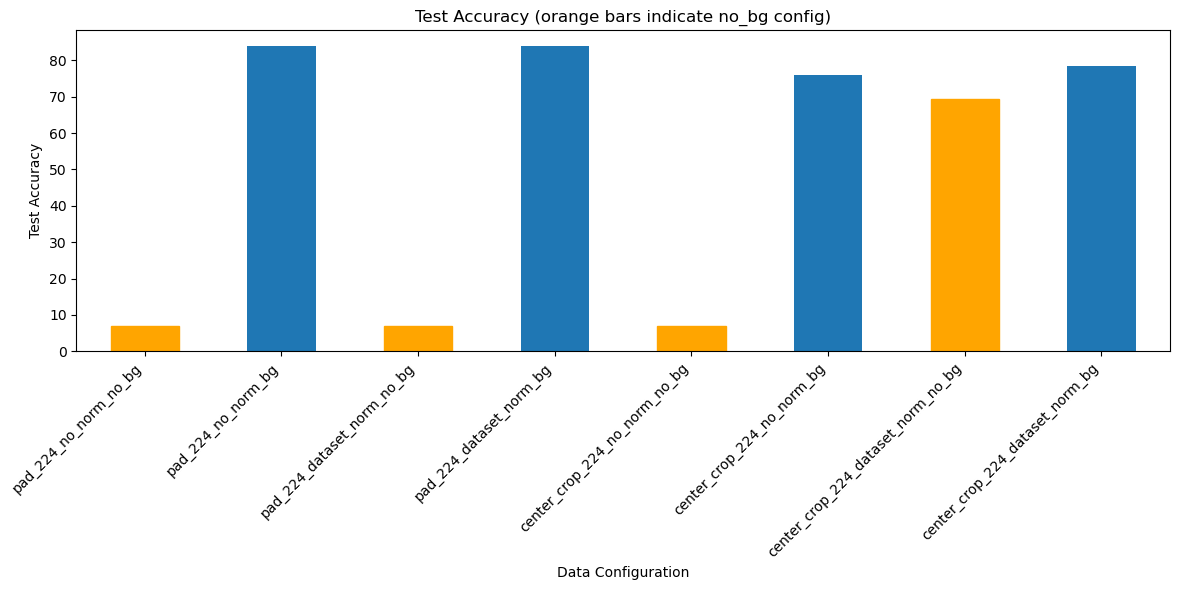

In [25]:
# Bar chart comparing the test accuracy for each fold
plot_metrics(results_df, "test_acc", "Test Accuracy")

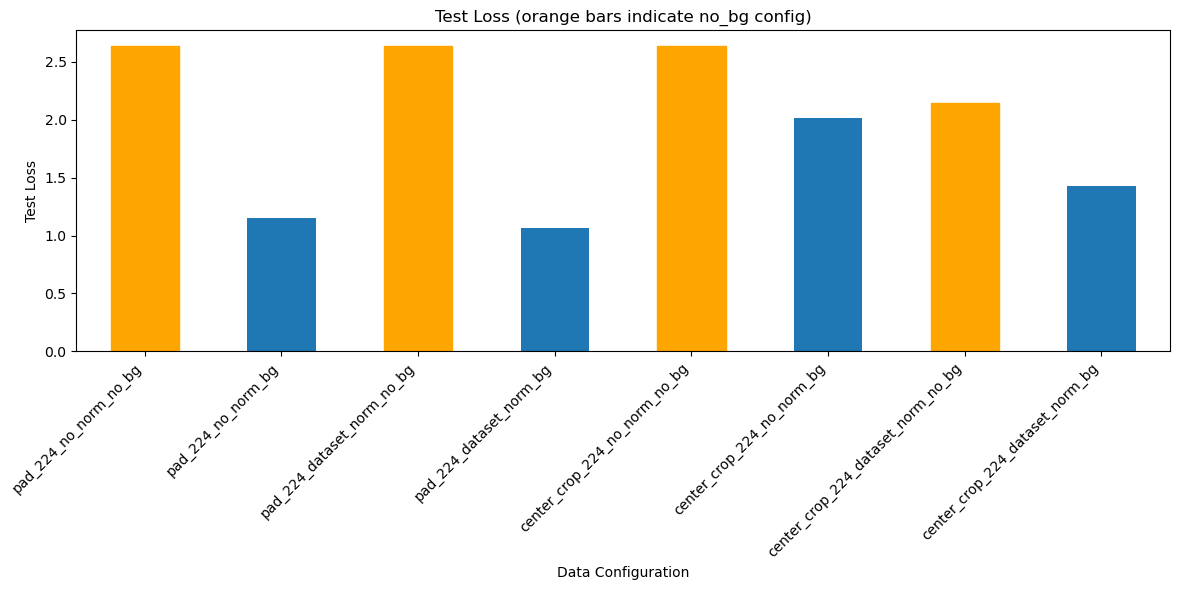

In [26]:
# Bar chart comparing the test loss for each fold
plot_metrics(results_df, "test_loss", "Test Loss")

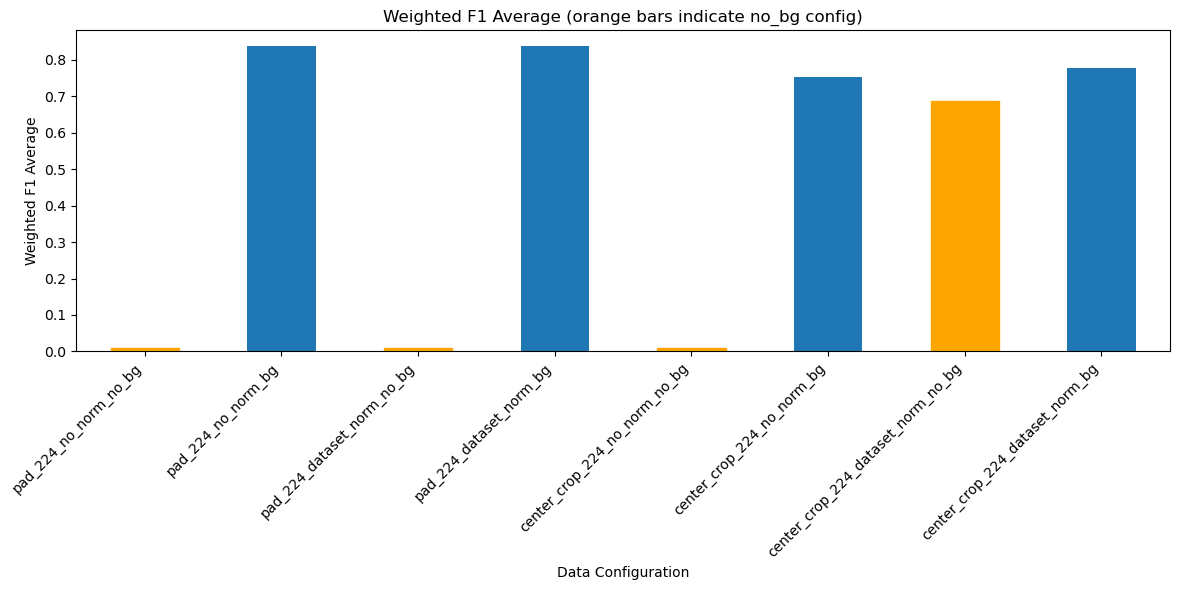

In [27]:
# Bar chart comparing the weighted F1 averages for each fold
plot_metrics(results_df, "weighted_f1_avg", "Weighted F1 Average")

#### Results
The best configuration was *pad_224_dataset_norm_bg*:

**Resize method:** Pad and then resize tactile images to 224x224. This makes sense because we would lose useful data from around the image edges when cropping.

**Normalisation:** Normalise tactile images using the train split mean and std.

**Background subtraction:** Subtract the baseline.jpg image (DIGIT output when no contact with an object is made). This helps remove sensor noise.

This configuration had the highest test accuracy (84.01%), weighted F1 average(0.84) and lowest test loss (1.07).

#### Updating Config File
Now we have our optimal set of paramaters, we should save the dictionary for use in the next experiments.

In [28]:
# Get best data config dictionary
best_config_index = titles.index("pad_224_dataset_norm_bg")
best_data_config = data_configs[best_config_index]
best_data_config

{'random_state': 129,
 'split_size': 0.2,
 'stratify_label': 'object',
 'filtered_force_level': None,
 'filtered_motion': None,
 'transform_name': 'pad_224',
 'bg_path': '../data/baseline.jpg',
 'norm_type': 'dataset',
 'norm_cache_path': '../configs/norm_cache.json',
 'batch_size': 64,
 'num_workers': 0,
 'shuffle_map': {'train': True, 'val': False, 'test': False}}

## Testing Random Cropping
Now we know that padding outperforms centre cropping, we can try random cropping to see if that outperforms padding (might possibly aid with overfitting).

#### Load Data

In [29]:
# Start with the best data config from the first experiment
data_config = best_data_config.copy()
# Update the transform name to random_crop_224
data_config["transform_name"] = "random_crop_224"

In [30]:
# Get the dataloaders
# We don't need the label mappings again as we are using the same training set
(
    dataloaders,
    _,
) = get_dataloaders(data_config)

Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.


#### Training

In [31]:
# Use the same model training configuration but update the title
train_config["model_title"] = "random_crop_224_dataset_norm_bg"

In [32]:
# Initialise the model
model = BaselineCNNModel(num_classes=num_train_classes)
# Train the model and save the history
model, history = train_classifier(
    model=model,
    device=device,
    train_loader=dataloaders["train"],
    val_loader=dataloaders["val"],
    target_label="object",
    train_config=train_config,
)

Starting training of random_crop_224_dataset_norm_bg on device: cuda


Epoch 1/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

Epoch 1/4 - Val:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 1/4 - Train Loss: 0.6974, Train Acc: 76.69%, Val Loss: 1.0865, Val Acc: 73.04%


Epoch 2/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

...

Epoch 3/4 - Val:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 3/4 - Train Loss: 0.1669, Train Acc: 94.57%, Val Loss: 1.2380, Val Acc: 76.17%


Epoch 4/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

Epoch 4/4 - Val:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 4/4 - Train Loss: 0.1282, Train Acc: 95.88%, Val Loss: 1.3875, Val Acc: 74.06%
Loaded best model checkpoint from epoch 3.


#### Evaluation

In [33]:
# Evaluate the model on the test set
results = eval_classifier(
    model=model,
    model_title=train_config["model_title"],
    device=device,
    test_loader=dataloaders["test"],
    target_label="object",
)

Starting evaluation of random_crop_224_dataset_norm_bg on device: cuda


Test:   0%|          | 0/190 [00:00<?, ?it/s]

Test Loss: 1.2571, Test Accuracy: 75.63%
Weighted F1 Average: 0.7498


#### Results
pad_224 results vs random_crop_224 results: 

**Test accuracy:** 84.01% vs 75.63%

**Test loss:** 1.07 vs 1.26

**F1 score:** 0.84 vs 0.75

The padding version outperforms the random crop version in all metrics, thereore we will keep padding as the chosen transform.

## Testing ImageNet Normalisation
The last thing we want to test is whether using the ImageNet normalisation values outperforms using the dataset normalisation values, when using a pre-trained ImageNet backbone.

For this we will use a pretrained ImageNet ResNet CNN and run it with both types of normalisation to compare. ImageNet normalisation is usually recommended when using pretrained models, but as tactile images are so different from standard RGB images, it is probable that dataset normalisation works best.

#### Load Data

In [34]:
# Start with the best data config from the first experiment
data_config = best_data_config.copy()
# Create a new config for imagenet normalisation
data_config_2 = data_config.copy()
data_config_2["norm_type"] = "imagenet"

In [35]:
# Get (dataloaders, label_info) tuples for each fold using the different data configs
data_configs = [data_config, data_config_2]
data = [get_dataloaders(cfg) for cfg in data_configs]
# Get the dataloaders
# We don't need the label mappings again as we are using the same training set
dataloaders = [item[0] for item in data]

Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 96720, Val: 12120, Test: 12120
Loading imagenet normalisation stats.


#### Training

In [ ]:
# Create a list of train configs for each fold
train_configs = [train_config.copy() for _ in range(2)]
# Use the same model training configuration but update the titles
train_configs[0]["model_title"] = "resnet_dataset_norm"
train_configs[1]["model_title"] = "resnet_imagenet_norm"

In [ ]:
# Train and validate the model for each fold using the corresponding dataloaders
models = []
histories = []

for i in range(len(dataloaders)):
    # Re-initialize the model for each fold
    model = PretrainedModel(model_type="resnet18", num_classes=num_train_classes)
    # Train the model and save the history
    model, history = train_classifier(
        model=model,
        device=device,
        train_loader=dataloaders[i]["train"],
        val_loader=dataloaders[i]["val"],
        target_label="object",
        train_config=train_configs[i],
    )
    models.append(model)
    histories.append(history)
    print("-----")

Starting training of resnet_dataset_norm on device: cuda


Epoch 1/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

Epoch 1/4 - Val:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 1/4 - Train Loss: 0.1734, Train Acc: 94.25%, Val Loss: 0.6686, Val Acc: 83.42%


Epoch 2/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

...

Epoch 3/4 - Train Loss: 0.0222, Train Acc: 99.31%, Val Loss: 0.5256, Val Acc: 87.53%


Epoch 4/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

Epoch 4/4 - Val:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 4/4 - Train Loss: 0.0273, Train Acc: 99.17%, Val Loss: 0.4336, Val Acc: 91.01%
Loaded best model checkpoint from epoch 4.
-----
Starting training of resnet_imagenet_norm on device: cuda


Epoch 1/4 - Train:   0%|          | 0/1512 [00:00<?, ?it/s]

#### Evaluation

In [ ]:
# Evaluate the model for each fold on the test set
results = []
for i in range(len(dataloaders)):
    model = models[i]
    result = eval_classifier(
        model=model,
        model_title=train_configs[i]["model_title"],
        device=device,
        test_loader=dataloaders[i]["test"],
        target_label="object",
    )
    results.append(result)
    print("-----")

Starting evaluation of resnet_dataset_norm on device: cuda


Test:   0%|          | 0/285 [00:00<?, ?it/s]

Test Loss: 0.4796, Test Accuracy: 89.31%
Weighted F1 Average: 0.8924
Starting evaluation of resnet_imagenet_norm on device: cuda


Test:   0%|          | 0/285 [00:00<?, ?it/s]

Test Loss: 0.9084, Test Accuracy: 77.28%
Weighted F1 Average: 0.7681


: 

#### Results
Although dataset normalisation slightly outperforms the Imagenet normalisation, the gains are very marginal. Therefore, it may be preferable to use Imagenet normalisation because of the saving in computational cost (no need to calculate mean and std from thousands of images). We will leave the default_data_config.json file with the existing dataset normalisation parameter (used with baesline CNNs anyway), but can manually update it to use Imagenet normalisation as and when required.